Proyecto Estadística 
---
---
Se entrega el proyecto de estadística hecho por Marcos Aldana, Nacho Ibañez, Carme Merli y Ana Die. 
Se trata de una simulación de un bosque europeo a lo largo de 3 años, en este hay tres tipos de plantas.
- Un arbol, especificamente un Roble.
- Un seto, concretamente un Romero.
- Hierba común.

Cada planta tiene unas condiciones distintas de crecimientos, a lo largo del tiempo crecerán debido a las lluvias por estación. Por tema de recursos hemos simplificado todo lo posible y hemos hecho que una lluvia por estación agrupe todas las lluvias por esa misma estación, es decir, que hay 12 lluvias en 3 años.

Las lluvias se han hecho con el Método Montecarlo, hemos definido un espacio en el que haremos un bombardeo de puntos que representaran las gotas, por lo se tendra que analizar que gotas han caido en cada arbol y como crecen, pudiendo así simular un bosque y como evoluciona.


Librerias utilizadas
---
---

In [26]:
#librerias
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.animation import FuncAnimation, PillowWriter

Creación y definición de variables.
---
---

In [27]:
#Arbol
nombre_roble='Roble'
posicion_roble=[]
lluvia_roble=[] #lluvia recogida por el roble
lluvia_roble_temp=[] 
tamano_roble=[] 
porsibles_tamano_roble=[3, 4, 5, 7]
aguacecer_roble=[25,50,300] #Umbrales de crecimiento del roble: n0 (semilla) -> n1 (brote) / n1 -> n2 (arbol) / n3 -> n4 (arbol final)
aguamorir_roble=[0,5,3,1]  #Umbrales de muerte (si no recibe x gotas durante t tiempo muere) un umbral para cada tipo
sequez_roble=[] #Estado muerto del árbol
vida_roble=[] # Estado vivo del árbol

#arbusto / Se repiten mismas variables con diferentes nombres
nombre_romero='Romero'
posicion_romero=[]
lluvia_romero=[]
lluvia_romero_temp=[]
tamano_romero=[]
porsibles_tamano_romero=[1,2,3, 4]
aguacecer_romero=[10,25,100]
aguamorir_romero=[0,7,5,1]
sequez_romero=[]
vida_romero=[]


#planucha / Se repiten mismas variables con diferentes nombres
nombre_hierba='Hierbas'
posicion_hierba=[]
lluvia_hierba=[]
lluvia_hierba_temp=[]
tamano_hierba=[]
porsibles_tamano_hierba=[2, 4, 16, 32]
aguacecer_hierba=[5,15,30]
aguamorir_hierba=[0,1,5,10]
sequez_hierba=[]
vida_hierba=[]

#estaciones invierno, primavera, verano, otoño
lluvia_estaciones=[450000,250000,50000,550000]


Posición inicial semillas + espacio inicial
---
---

Definimos un espacio 1000x1000 y creamos los objetos con sus respectivas posiciones. 
Para diferenciar entre objetos asignamos un color por cada tipo de vegetación.
- Roble = azul. 
- Romero = amarillo.
- Hierba común = verde.

Mostramos por pantalla donde han sido asignados los objetos.  

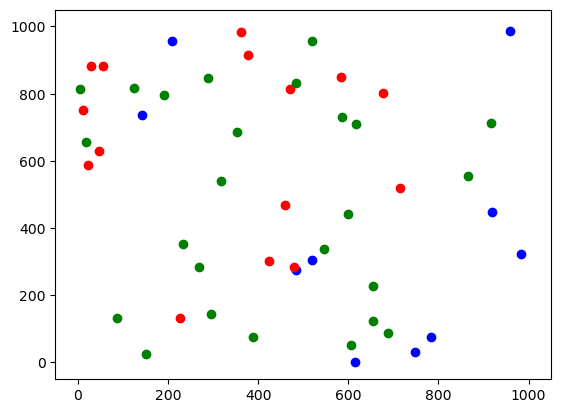

In [28]:
#posición inicial semillas+espacio inicial

x = np.linspace(0, 1000, num=1001)

y = np.linspace(0, 1000, num=1001)

X, Y = np.meshgrid(x, y)

def generar_planta(
        numero,                          # nº total de plantas a colocar
        radio,                       # radio mínimo para todas las plantas
    ):
    posiciones = []   

    for i in range(numero): 
        pos=np.random.randint((1001-radio), size=(1, 2)) #Generamos con un random todas las semillas en el plano (posición aleatoria)
        pos_gran= [pos[0][0]+radio,pos[0][1]+radio]
        posiciones.append(pos)
    return np.array(posiciones)

# Crear el bosque

numero_robles=10
numero_romero=15
numero_hierba=25

posicion_roble = generar_planta(
    numero_robles,
    radio=porsibles_tamano_roble[3]
)
for i in range(numero_robles): #Variables iniciales para cada roble de todo le búcle
    vida_roble.append('Vivo')
    lluvia_roble.append(0)
    tamano_roble.append(porsibles_tamano_roble[0])
    lluvia_roble_temp.append(0)
    sequez_roble.append(0)

    

posicion_romero = generar_planta(
    numero_romero,
    radio=porsibles_tamano_romero[3]
)
for i in range(numero_romero): #Variables iniciales para cada arbusto de todo le búcle
    vida_romero.append('Vivo')
    lluvia_romero.append(0)
    tamano_romero.append(porsibles_tamano_romero[0])
    lluvia_romero_temp.append(0)
    sequez_romero.append(0)



posicion_hierba = generar_planta(
    numero_hierba,
    radio=porsibles_tamano_hierba[3]
)
for i in range(numero_hierba): #Variables iniciales para cada plantucha de todo le búcle
    vida_hierba.append('Vivo')
    lluvia_hierba.append(0)
    tamano_hierba.append(porsibles_tamano_hierba[0])
    lluvia_hierba_temp.append(0)
    sequez_hierba.append(0)

plt.scatter(X,Y, c="w") #Generamos el gráfico base de 1000 x 1000 que luego tendrá por encima las siguientes gráficas:

#Gráficas de puntos de las posiciones de los objetos
j = 0
for j in range(len(posicion_roble)):
    plt.scatter(posicion_roble[j][0][0],posicion_roble[j][0][1], c="b")

#plt.show()

for j in range(len(posicion_romero)):
    plt.scatter(posicion_romero[j][0][0],posicion_romero[j][0][1], c="r")

#plt.show()

for j in range(len(posicion_hierba)):
    plt.scatter(posicion_hierba[j][0][0],posicion_hierba[j][0][1], c="g")


Ciclo de la Lluvia 
---
---

In [29]:
# ==========================================
# 1. DEFINICIÓN DE FUNCIONES (¡IMPORTANTE!)
# ==========================================

def lluvia(num_gotas):
    # Genera gotas aleatorias
    gotas = np.random.randint(1001, size=(num_gotas, 2))
    return gotas

def dentro_circulo(arbol_x, arbol_y, gota_x, gota_y, tamano_arbol):
    # Comprueba si una gota cae dentro del radio
    # Usamos la fórmula de distancia al cuadrado que es más rápida
    if ((gota_x - arbol_x)**2 + (gota_y - arbol_y)**2 <= tamano_arbol**2):
        return True
    else:
        return False

# ==========================================
# 2. PREPARACIÓN DE HISTORIAL
# ==========================================
historia_roble_tam = [list(tamano_roble)] 
historia_roble_vida = [list(vida_roble)]

historia_romero_tam = [list(tamano_romero)]
historia_romero_vida = [list(vida_romero)]

historia_hierba_tam = [list(tamano_hierba)]
historia_hierba_vida = [list(vida_hierba)]

# ==========================================
# 3. BUCLE DE SIMULACIÓN
# ==========================================
a=0
s=0
b=0

# Bucle de 12 estaciones
for i in range(12): 
    # Logica de cambio de estación
    if b==3:
       a=a+1 
    b=s-a*4
    
    print(f"Procesando Estación {i+1} (Tipo {b}, Lluvia: {lluvia_estaciones[b]})...")
    
    # Generar lluvia
    lluvia_total = lluvia(lluvia_estaciones[b])
    
    # Reset de contadores temporales
    for k in range(len(lluvia_roble_temp)): lluvia_roble_temp[k]=0
    for k in range(len(lluvia_romero_temp)): lluvia_romero_temp[k]=0
    for k in range(len(lluvia_hierba_temp)): lluvia_hierba_temp[k]=0

    # ---------------- ROBLES ----------------
    for numero_arbol in range(len(posicion_roble)):
        # Optimización: chequeo previo de vida
        if vida_roble[numero_arbol]=='Vivo':
            for numero_gota in range(len(lluvia_total)):
                temp_roble=dentro_circulo(posicion_roble[numero_arbol][0][0], posicion_roble[numero_arbol][0][1], lluvia_total[numero_gota][0], lluvia_total[numero_gota][1], tamano_roble[numero_arbol])
                if temp_roble==True:
                    lluvia_roble[numero_arbol]+=1
                    lluvia_roble_temp[numero_arbol]+=1

            # Crecimiento Roble
            try:
                nivel_actual = porsibles_tamano_roble.index(tamano_roble[numero_arbol])
                if nivel_actual<3:
                    if lluvia_roble[numero_arbol] >= aguacecer_roble[nivel_actual]:
                        tamano_roble[numero_arbol] = porsibles_tamano_roble[nivel_actual + 1]
            except ValueError: pass

            # Muerte Roble
            nivel_actual = porsibles_tamano_roble.index(tamano_roble[numero_arbol])
            if (lluvia_roble_temp[numero_arbol]) < aguamorir_roble[nivel_actual]:
                sequez_roble[numero_arbol]+=1
                if sequez_roble[numero_arbol]==3:
                    vida_roble[numero_arbol] = 'Muerto'
                    sequez_roble[numero_arbol]=0

    # ---------------- ROMEROS ----------------
    for numero_arbusto in range(len(posicion_romero)):
        if vida_romero[numero_arbusto]=='Vivo':
            for numero_gota in range(len(lluvia_total)):
                temp_romero=dentro_circulo(posicion_romero[numero_arbusto][0][0], posicion_romero[numero_arbusto][0][1], lluvia_total[numero_gota][0], lluvia_total[numero_gota][1], tamano_romero[numero_arbusto])
                if temp_romero==True:
                    lluvia_romero[numero_arbusto]+=1
                    lluvia_romero_temp[numero_arbusto]+=1

            # Crecimiento Romero
            try:
                nivel_actual = porsibles_tamano_romero.index(tamano_romero[numero_arbusto])
                if nivel_actual<3:
                    if lluvia_romero[numero_arbusto] >= aguacecer_romero[nivel_actual]:
                        tamano_romero[numero_arbusto] = porsibles_tamano_romero[nivel_actual + 1]
            except ValueError: pass

            # Muerte Romero
            nivel_actual = porsibles_tamano_romero.index(tamano_romero[numero_arbusto])
            if (lluvia_romero_temp[numero_arbusto]) < aguamorir_romero[nivel_actual]:
                sequez_romero[numero_arbusto]+=1
                if sequez_romero[numero_arbusto]==2:
                    if tamano_romero[numero_arbusto]==porsibles_tamano_romero[0]:
                        vida_romero[numero_arbusto] = 'Muerto'
                    else:
                        tamano_romero[numero_arbusto] = porsibles_tamano_romero[nivel_actual - 1]
                        sequez_romero[numero_arbusto]=0

    # ---------------- HIERBAS ----------------
    for numero_hierba_1 in range(len(posicion_hierba)): 
        if vida_hierba[numero_hierba_1]=='Vivo':
            for numero_gota in range(len(lluvia_total)):
                temp_hierba=dentro_circulo(posicion_hierba[numero_hierba_1][0][0], posicion_hierba[numero_hierba_1][0][1], lluvia_total[numero_gota][0], lluvia_total[numero_gota][1], tamano_hierba[numero_hierba_1])
                if temp_hierba==True:
                    lluvia_hierba[numero_hierba_1]+=1
                    lluvia_hierba_temp[numero_hierba_1]+=1

            # Crecimiento Hierba
            try:
                nivel_actual = porsibles_tamano_hierba.index(tamano_hierba[numero_hierba_1])
                if nivel_actual<3:
                    if lluvia_hierba[numero_hierba_1] >= aguacecer_hierba[nivel_actual]:
                        tamano_hierba[numero_hierba_1] = porsibles_tamano_hierba[nivel_actual + 1]
            except ValueError: pass

            # Muerte Hierba
            nivel_actual = porsibles_tamano_hierba.index(tamano_hierba[numero_hierba_1])     
            if (lluvia_hierba_temp[numero_hierba_1]) < aguamorir_hierba[nivel_actual]:
                sequez_hierba[numero_hierba_1]+=1
                if sequez_hierba[numero_hierba_1]==1:
                    if tamano_hierba[numero_hierba_1]==porsibles_tamano_hierba[0]:
                        vida_hierba[numero_hierba_1] = 'Muerto'
                    else:
                        tamano_hierba[numero_hierba_1] = porsibles_tamano_hierba[nivel_actual - 1]
                        sequez_hierba[numero_hierba_1]=0

    # --- GUARDAR HISTORIAL ---
    historia_roble_tam.append(list(tamano_roble))
    historia_roble_vida.append(list(vida_roble))
    
    historia_romero_tam.append(list(tamano_romero))
    historia_romero_vida.append(list(vida_romero))
    
    historia_hierba_tam.append(list(tamano_hierba))
    historia_hierba_vida.append(list(vida_hierba))

    s=s+1

print("Simulación terminada.")

Procesando Estación 1 (Tipo 0, Lluvia: 450000)...
Procesando Estación 2 (Tipo 1, Lluvia: 250000)...
Procesando Estación 3 (Tipo 2, Lluvia: 50000)...
Procesando Estación 4 (Tipo 3, Lluvia: 550000)...
Procesando Estación 5 (Tipo 0, Lluvia: 450000)...
Procesando Estación 6 (Tipo 1, Lluvia: 250000)...
Procesando Estación 7 (Tipo 2, Lluvia: 50000)...
Procesando Estación 8 (Tipo 3, Lluvia: 550000)...
Procesando Estación 9 (Tipo 0, Lluvia: 450000)...
Procesando Estación 10 (Tipo 1, Lluvia: 250000)...
Procesando Estación 11 (Tipo 2, Lluvia: 50000)...
Procesando Estación 12 (Tipo 3, Lluvia: 550000)...
Simulación terminada.


Descarga de Lluvias en formato GIF.
---
---

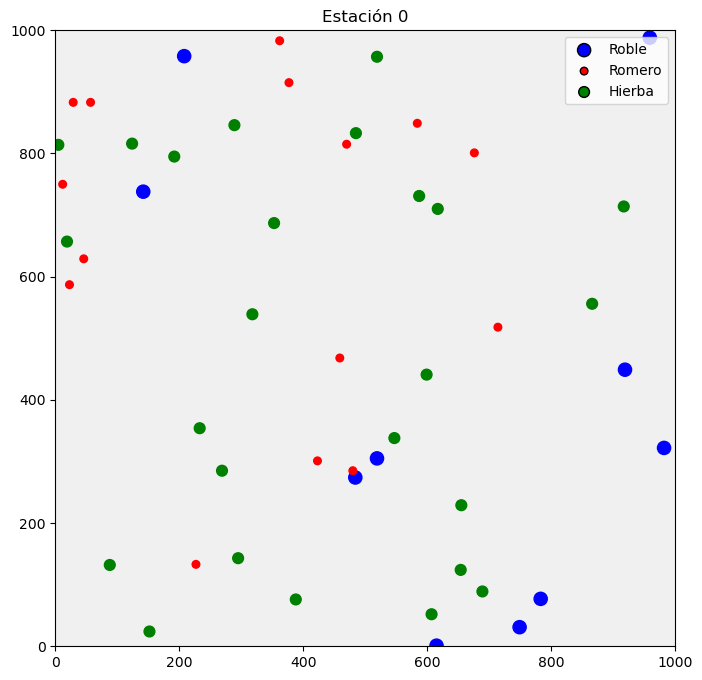

In [30]:
# --- CÓDIGO DE ANIMACIÓN CORREGIDO ---
from IPython.display import HTML

# 1. Configurar la Figura
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_title("Evolución del Bosque")
ax.set_facecolor('#f0f0f0') 

# 2. Extraer coordenadas X e Y limpias
x_roble = [p[0][0] for p in posicion_roble]
y_roble = [p[0][1] for p in posicion_roble]

x_romero = [p[0][0] for p in posicion_romero]
y_romero = [p[0][1] for p in posicion_romero]

x_hierba = [p[0][0] for p in posicion_hierba]
y_hierba = [p[0][1] for p in posicion_hierba]

# 3. PREPARAR ESTADO INICIAL (Esto es lo que faltaba)
# Matplotlib necesita saber los tamaños iniciales para no dar error.
# Multiplicamos por 30 para que se vean bien (mismo factor que usaremos luego)

# Roble
s_roble_init = [t * 30 for t in historia_roble_tam[0]]
c_roble_init = ['blue' if v == 'Vivo' else 'black' for v in historia_roble_vida[0]]

# Romero
s_romero_init = [t * 30 for t in historia_romero_tam[0]]
c_romero_init = ['red' if v == 'Vivo' else 'black' for v in historia_romero_vida[0]]

# Hierba
s_hierba_init = [t * 30 for t in historia_hierba_tam[0]]
c_hierba_init = ['green' if v == 'Vivo' else 'black' for v in historia_hierba_vida[0]]


# 4. Crear los objetos Scatter CON DATOS INICIALES
scat_roble = ax.scatter(x_roble, y_roble, s=s_roble_init, c=c_roble_init, label='Roble', edgecolors='black')
scat_romero = ax.scatter(x_romero, y_romero, s=s_romero_init, c=c_romero_init, label='Romero', edgecolors='black')
scat_hierba = ax.scatter(x_hierba, y_hierba, s=s_hierba_init, c=c_hierba_init, label='Hierba', edgecolors='black')

# Leyenda
ax.legend(loc="upper right")

# 5. Función de actualización
def update(frame):
    ax.set_title(f"Estación {frame}")
    
    # --- Actualizar ROBLES ---
    tamanos = historia_roble_tam[frame]
    vidas = historia_roble_vida[frame]
    colores = ['blue' if v == 'Vivo' else 'black' for v in vidas]
    sizes_screen = [t * 30 for t in tamanos]
    
    scat_roble.set_sizes(sizes_screen)
    scat_roble.set_color(colores)
    
    # --- Actualizar ROMEROS ---
    tamanos = historia_romero_tam[frame]
    vidas = historia_romero_vida[frame]
    colores = ['red' if v == 'Vivo' else 'black' for v in vidas]
    sizes_screen = [t * 30 for t in tamanos]
    
    scat_romero.set_sizes(sizes_screen)
    scat_romero.set_color(colores)
    
    # --- Actualizar HIERBAS ---
    tamanos = historia_hierba_tam[frame]
    vidas = historia_hierba_vida[frame]
    colores = ['green' if v == 'Vivo' else 'black' for v in vidas]
    sizes_screen = [t * 30 for t in tamanos]
    
    scat_hierba.set_sizes(sizes_screen)
    scat_hierba.set_color(colores)
    
    return scat_roble, scat_romero, scat_hierba

# 6. Crear la animación
ani = FuncAnimation(fig, update, frames=len(historia_roble_tam), interval=800, blit=False)

# 7. Mostrar
HTML(ani.to_jshtml())